# QAOA Implementation Part III: Quantum Circuit Construction and Measurement

**Sehong Park and Adolfo Menendez Rua · Physics 565 / 656 · Spring 2026**

This notebook builds the explicit Qiskit circuit for QAOA on $C_{10}$ at $p = 1, 2, 3$ and inspects the measurement distributions. It complements NB 04 (which compares optimisers and warm-start strategies on the same graphs): we *use* the optimal $(\gamma, \beta)$ found there to construct the actual gate-level circuit, transpile it, run it on the Aer simulator with $\sim 8000$ shots, and look at the resulting bitstring histograms.

**Workflow.**
1. Build the three benchmark graphs ($C_{10}$, $C_{10}$ + 3 chords, 3-regular $n = 10$).
2. Run a noiseless statevector QAOA (COBYLA + 20 random restarts) to obtain optimal $(\gamma, \beta)$ for $p = 1, 2, 3$. This serves as the parameter source for the circuit construction below; values are consistent with the warm-start parameters NB 04 exports to `../Results/optimal_params.json`.
3. For $C_{10}$, write out the explicit Qiskit circuit at each depth: Hadamard layer → $U_C(\gamma)$ as $\prod_{(i,j)\in E}\,\mathrm{CNOT}\text{–}R_Z(-\gamma)\text{–}\mathrm{CNOT}$ → $U_B(\beta)$ as $\bigotimes_i R_X(2\beta)$ → measurement.
4. Transpile, run, and read out shot histograms.

**$U_C(\gamma)$ on $C_{10}$.** Product over 10 edges of CNOT–$R_Z(-\gamma)$–CNOT blocks. At the optimal $\gamma \approx 0.79$: 20 CX + 10 $R_Z$ gates per layer.

**$U_B(\beta)$ on $C_{10}$.** $R_X(2\beta)$ on every qubit. At $\beta \approx 1.96$: 10 single-qubit rotations per layer, no entangling gates.

**What the histograms show.** The two MaxCut bitstrings $|1010101010\rangle$ and $|0101010101\rangle$ (cut value $10$) carry most of the probability, and $p = 3$ concentrates probability on them more sharply than $p = 1$. The complementary pair $\{z, \bar z\}$ appears with nearly equal weight in every histogram — a consequence of the $\mathbb{Z}_2$ symmetry of MaxCut ($C(z) = C(\bar z)$).

See [README.md](README.md) for the full Implementation chapter walkthrough.

---
## 1. Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

MASTER_SEED = 42
np.random.seed(MASTER_SEED)

# ── Core utilities ─────────────────────────────────────────────────
def cut_val(bits, edges):
    return sum(1 for i,j in edges if bits[i] != bits[j])

def exact_maxcut(edges, n):
    """Brute-force exact MaxCut (n ≤ 20)."""
    best = 0
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        best = max(best, cut_val(bits, edges))
    return best

print("Setup complete.")

Setup complete.


---
## 2. Graph Instances

| Graph | Structure | Role |
|-------|-----------|------|
| $C_{10}$ | 10-cycle | Sanity check; QAOA theoretically analyzed (2-regular) |
| $C_{10}$ + 3 chords | Cycle + long-range edges | Local structure disrupted; greedy struggles |
| 3-regular ($n=10$) | All degrees = 3 | Directly analyzed in Farhi et al. (2014) |

These three instances represent distinct structural regimes: a 2-regular cycle (analytically tractable), a cycle with long-range edges (disrupted locality), and a 3-regular graph (studied directly in Farhi et al. 2014).


In [2]:
n = 10

# ── C10 ──────────────────────────────────────────────────────────
G1 = nx.cycle_graph(n)
e1 = list(G1.edges())

# ── C10 + 3 chords ───────────────────────────────────────────────
G2 = nx.cycle_graph(n)
non_edges = [(i,j) for i in range(n) for j in range(i+2, n)
             if abs(i-j) > 1 and not (i == 0 and j == n-1)]
chord_idx = np.random.default_rng(0).choice(len(non_edges), size=3, replace=False)
CHORDS = [non_edges[c] for c in chord_idx]
for c in CHORDS:
    G2.add_edge(*c)
e2 = list(G2.edges())

# ── 3-regular n=10 ───────────────────────────────────────────────
G3 = nx.random_regular_graph(3, n, seed=7)
e3 = list(G3.edges())

GRAPHS = [
    (r'$C_{10}$',            G1, e1),
    (r'$C_{10}$ + 3 chords', G2, e2),
    (r'3-regular ($n=10$)',   G3, e3),
]

for name, G, edges in GRAPHS:
    opt = exact_maxcut(edges, n)
    print(f"{name}: |E|={len(edges)}, OPT={opt}, avg_degree={2*len(edges)/n:.1f}")
print(f"Chords added to G2: {CHORDS}")


$C_{10}$: |E|=10, OPT=10, avg_degree=2.0
$C_{10}$ + 3 chords: |E|=13, OPT=13, avg_degree=2.6
3-regular ($n=10$): |E|=15, OPT=13, avg_degree=3.0
Chords added to G2: [(3, 6), (2, 7), (4, 9)]


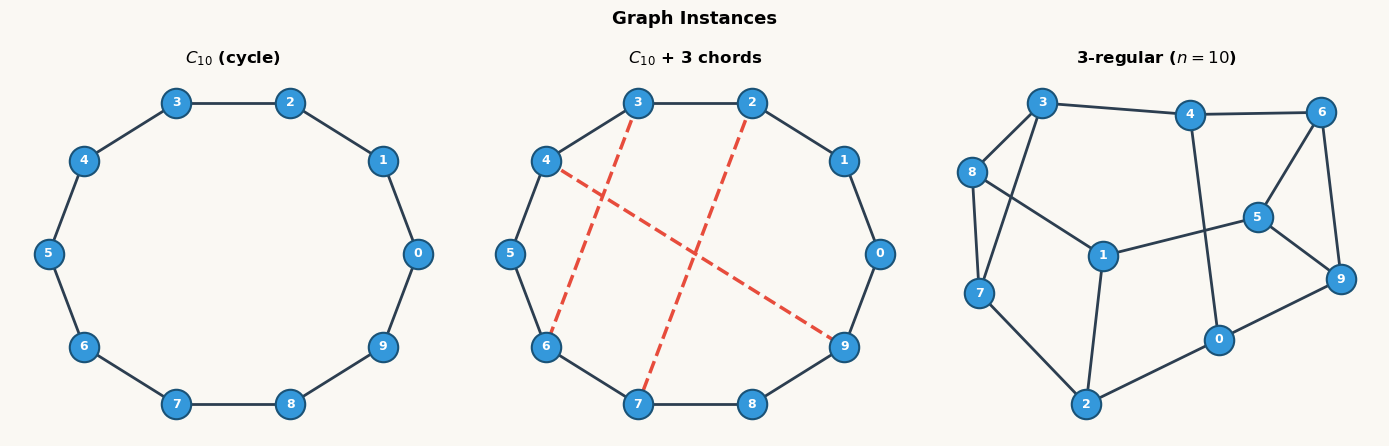

In [3]:
# ── Visualize ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor("#FAF8F3")  # <-- bckg color
titles = [r'$C_{10}$ (cycle)', r'$C_{10}$ + 3 chords', r'3-regular ($n=10$)']

for ax, (name, G, edges), title in zip(axes, GRAPHS, titles):
    pos = nx.circular_layout(G) if G in [G1, G2] else nx.spring_layout(G, seed=MASTER_SEED)

    if G is G2:
        cycle_e = list(nx.cycle_graph(n).edges())
        chord_e = [e for e in G.edges()
                   if e not in cycle_e and (e[1],e[0]) not in cycle_e]
        nx.draw_networkx_edges(G, pos, edgelist=cycle_e, ax=ax,
                               edge_color='#2C3E50', width=2)
        nx.draw_networkx_edges(G, pos, edgelist=chord_e, ax=ax,
                               edge_color='#E74C3C', width=2.5, style='dashed')
        # chord_patch = plt.Line2D([0],[0], color='#E74C3C', lw=2, ls='--', label='Chords')
        # cycle_patch = plt.Line2D([0],[0], color='#2C3E50', lw=2, label='Cycle')
        # ax.legend(handles=[cycle_patch, chord_patch], fontsize=8, loc='upper right')
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#2C3E50', width=2)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#3498DB',
                           node_size=450, edgecolors='#1A5276', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_size=9, font_weight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Graph Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_graphs.png', dpi=130, bbox_inches='tight')
plt.show()


### What MaxCut configurations should we expect?

For each graph, the QAOA histogram should peak on the **MaxCut bitstrings** — configurations $z \in \{0,1\}^{10}$ that achieve the optimal cut value $C_{\max}$. The $\mathbb{Z}_2$ symmetry $C(z) = C(\bar z)$ of MaxCut guarantees these come in complementary pairs (flip every bit, same cut).

We brute-force enumerate them below to know what to look for in the simulated histograms in §4 and §5.

In [4]:
def find_maxcut_bitstrings(edges, n):
    """Brute-force enumeration: return all bitstrings achieving max cut, plus C_max."""
    cuts_by_bits = {}
    for x in range(2**n):
        bits = tuple((x >> i) & 1 for i in range(n))
        cuts_by_bits[bits] = cut_val(bits, edges)
    cmax = max(cuts_by_bits.values())
    optimal = [b for b, c in cuts_by_bits.items() if c == cmax]
    return optimal, cmax

# Store for later reference
MAXCUT_BITSTRINGS = {}
for name, G, edges in GRAPHS:
    optimal, cmax = find_maxcut_bitstrings(edges, n)
    MAXCUT_BITSTRINGS[name] = (optimal, cmax)
    print(f"{name}: C_max = {cmax}, {len(optimal)} optimal bitstrings")
    for b in optimal[:4]:
        # Display with vertex 0 as leftmost (natural reading order)
        print(f"  |{''.join(map(str, b))}>")
    if len(optimal) > 4:
        print(f"  ... and {len(optimal) - 4} more (Z_2 partners included)")
    print()

$C_{10}$: C_max = 10, 2 optimal bitstrings
  |1010101010>
  |0101010101>

$C_{10}$ + 3 chords: C_max = 13, 2 optimal bitstrings
  |1010101010>
  |0101010101>

3-regular ($n=10$): C_max = 13, 2 optimal bitstrings
  |1101001100>
  |0010110011>



---
## 3. Statevector QAOA — Optimal Parameter Search

To build the Qiskit circuit in §4 we need optimal $(\gamma, \beta)$ for $C_{10}$ at $p = 1, 2, 3$. NB 04 already does this in detail (optimiser comparison + warm-start), and exports the result to `../Results/optimal_params.json`. Here we re-run a clean noiseless statevector optimisation for all three benchmark graphs as an independent check, and use the resulting $C_{10}$ parameters to drive the circuit construction below.

**Cost unitary** $U_C(\gamma) = e^{-i\gamma H_C}$: diagonal phase oracle, $O(2^n)$ in simulation, $O(|E|)$ circuit depth on hardware.

**Mixer unitary** $U_B(\beta) = \bigotimes_i e^{-i\beta X_i}$: separable, applied qubit by qubit.

**Optimiser:** COBYLA with 20 random restarts to avoid local minima.

In [5]:
# ── QAOA engine ──────────────────────────────────────────────────
def build_diag(edges, n):
    """Diagonal of H_C in the computational basis."""
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        d[x] = cut_val(bits, edges)
    return d

def apply_UB(psi, beta, n):
    """Apply mixer e^{-iβ H_B} qubit by qubit (separable: O(n·2^n))."""
    c, s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,q,0).reshape(2,-1)
        psi = np.array([c*psi[0]-1j*s*psi[1], -1j*s*psi[0]+c*psi[1]])
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,0,q)
    return psi.reshape(-1)

def run_qaoa(edges, n, p, n_restarts=20):
    """
    QAOA for MaxCut. Returns (best_ratio, best_params).
    Maximizes F_p = <psi_p | H_C | psi_p> via COBYLA.
    Parameter ordering: [γ_1, ..., γ_p, β_1, ..., β_p].
    """
    diag = build_diag(edges, n)
    OPT  = int(round(diag.max()))
    DIM  = 2**n

    def energy(theta):
        g = theta[:p]; b = theta[p:]
        psi = np.ones(DIM, dtype=complex) / np.sqrt(DIM)
        for k in range(p):
            psi = np.exp(-1j * g[k] * diag) * psi
            psi = apply_UB(psi, b[k], n)
        return -np.real(np.dot(psi.conj(), diag * psi))

    best = None
    for t in range(n_restarts):
        rng = np.random.default_rng(MASTER_SEED + t * 7)
        theta0 = rng.uniform(0, np.pi/2, 2*p)
        res = minimize(energy, theta0, method='COBYLA',
                       options={'maxiter': 800, 'rhobeg': 0.5})
        if best is None or res.fun < best.fun:
            best = res

    return -best.fun / OPT, best.x

# ── Run QAOA for all graphs and p = 1, 2, 3 ──────────────────────
results = {}
for name, G, edges in GRAPHS:
    opt = exact_maxcut(edges, n)
    qaoa_ratio = {}
    qaoa_params = {}
    for p in [1, 2, 3]:
        ratio, params = run_qaoa(edges, n, p)
        qaoa_ratio[p] = ratio
        qaoa_params[p] = params
    results[name] = {
        "optimal": opt,
        "ratio":   qaoa_ratio,
        "params":  qaoa_params,
    }
    print(f"{name}: OPT = {opt}")
    for p in [1, 2, 3]:
        print(f"  p = {p}: ratio = {qaoa_ratio[p]:.4f}, params = "
              f"{np.array2string(qaoa_params[p], precision=4)}")

$C_{10}$: OPT = 10
  p = 1: ratio = 0.7500, params = [0.7854 0.3927]
  p = 2: ratio = 0.8333, params = [0.6559 1.2429 0.6214 1.8988]
  p = 3: ratio = 0.8750, params = [0.5918 1.1557 1.3643 2.253  2.1488 1.8669]
$C_{10}$ + 3 chords: OPT = 13
  p = 1: ratio = 0.7070, params = [0.663  1.9635]
  p = 2: ratio = 0.7913, params = [0.5063 0.9236 2.1449 0.324 ]
  p = 3: ratio = 0.8718, params = [0.4855 0.8017 0.9462 0.6465 0.5563 0.3358]
3-regular ($n=10$): OPT = 13
  p = 1: ratio = 0.7753, params = [0.5882 1.9359]
  p = 2: ratio = 0.8510, params = [ 2.6333 -0.9205  2.0786  1.8523]
  p = 3: ratio = 0.9012, params = [0.4357 0.8696 1.0025 0.5386 1.9793 0.2306]


---
## 4. Qiskit Circuit Construction and Shot-Based Simulation

We now build the explicit gate-level Qiskit circuit on $C_{10}$ at $p = 1, 2, 3$, using the optimal $(\gamma, \beta)$ from §3 (`results[r'$C_{10}$']['params'][p]`). Each layer is

- **Hadamard** on every qubit (initial $|+\rangle^{\otimes n}$).
- **Cost unitary** $U_C(\gamma) = \prod_{(i,j)\in E}\,\mathrm{CNOT}_{ij}\,R_Z^{(j)}(-\gamma)\,\mathrm{CNOT}_{ij}$ — one block per edge, 20 CX + 10 $R_Z$ on $C_{10}$.
- **Mixer unitary** $U_B(\beta) = \bigotimes_i R_X^{(i)}(2\beta)$ — one single-qubit rotation per qubit.
- **Measurement** in the computational basis after the final layer.

Each circuit is transpiled with optimisation level 1 and run on `AerSimulator` with $4096 \times 2 = 8192$ shots.

### $C_{10}$ , p = 1

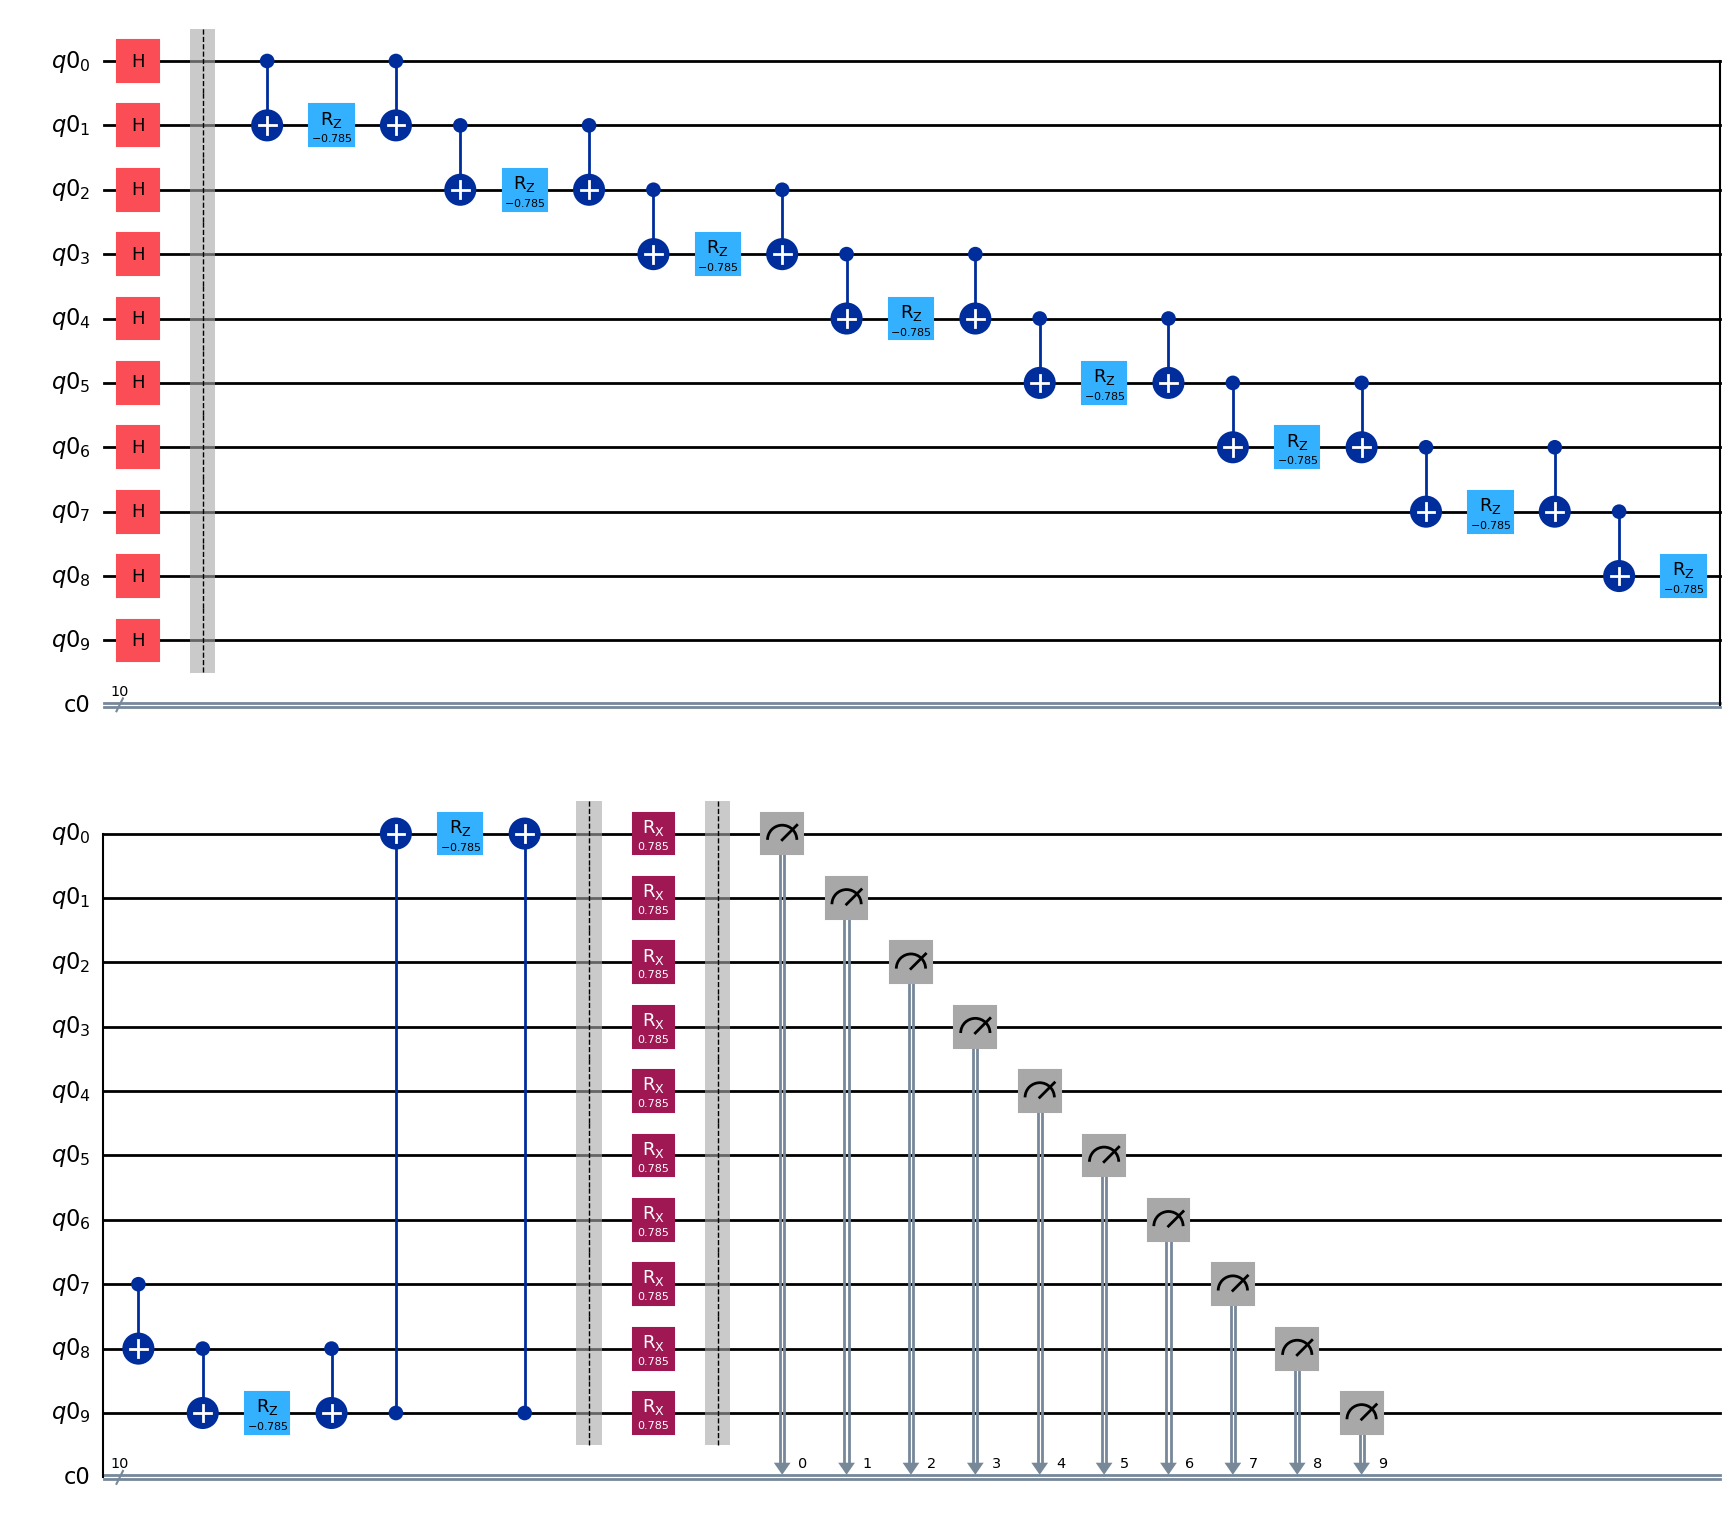

In [6]:
# Create the quantum circuit for C10, p=1
from qiskit import *
from qiskit.visualization import plot_histogram

# Optimal parameters from §3 (run_qaoa on C10 with p=1)
bestparams = results[r'$C_{10}$']['params'][1]   # [γ_1, β_1]

# create 10 quantum registers, one for each qubit
q = QuantumRegister(10)
# create 10 corresponding classical registers (needed for storing measurement results)
c = ClassicalRegister(10)
# create a quantum circuit with these registers
qaoa_qc = QuantumCircuit(q, c)

# Apply Hadamard gates to all qubits to create the initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()

# Apply the cost unitary U_C for C10
edges_c10 = [(i, (i+1) % 10) for i in range(10)]
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()

# Apply the mixer unitary U_B
for i in range(10):
    qaoa_qc.rx(2 * bestparams[1], q[i])      # β_1
qaoa_qc.barrier()

# Measure all qubits
qaoa_qc.measure(q, c)

# Visualize the circuit
qaoa_qc.draw(output='mpl', style='iqx')

{'0110101101': 77, '1101001010': 70, '0101001101': 70, '1010110010': 57, '0101100101': 84, '1001100100': 23, '0001110101': 4, '0101010101': 358, '0010110101': 57, '1001010101': 78, '1001000100': 6, '1010101110': 21, '1001010100': 73, '1010101100': 77, '0101000101': 14, '0010101010': 19, '1011011010': 74, '0010101101': 54, '1001010010': 59, '0011010101': 93, '1010110101': 77, '1110010100': 8, '0101101010': 60, '1100101100': 24, '0101110101': 27, '0100101100': 11, '1001011011': 2, '0110010101': 78, '0110111011': 4, '1110101100': 11, '1001101001': 13, '0111010101': 16, '1101011010': 66, '1001000101': 5, '0001001011': 4, '1101000110': 5, '0010011101': 4, '0100011010': 5, '1001001010': 80, '0101101001': 49, '1011001010': 66, '0101100011': 10, '0101001001': 69, '1011001101': 22, '0110101011': 64, '0010011010': 4, '0100101011': 65, '1111001011': 1, '0010101011': 74, '0101001100': 7, '0101101101': 45, '0110101010': 64, '1011010110': 76, '1101001110': 6, '1010101010': 332, '0001101011': 4, '110

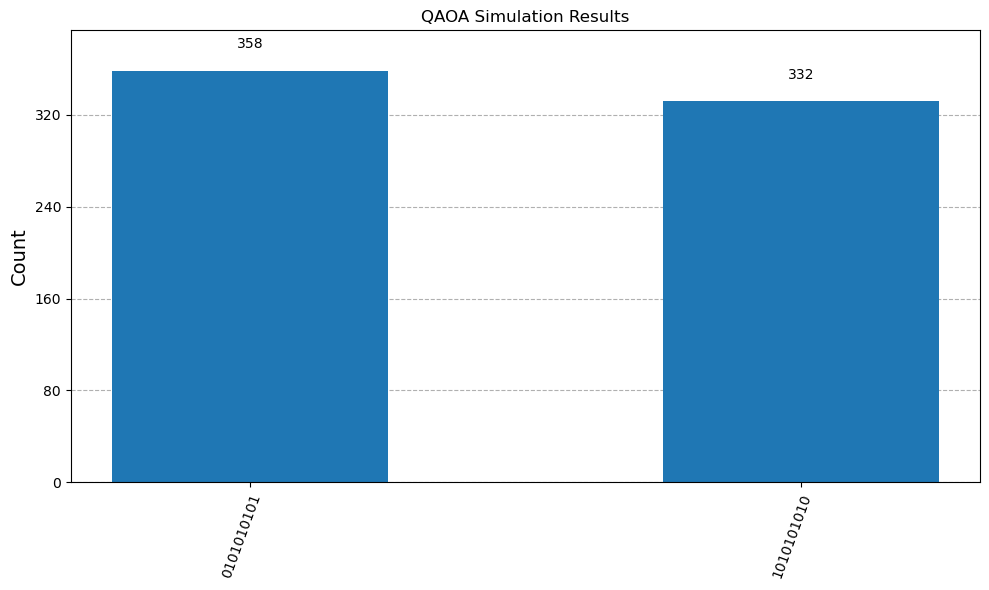

In [7]:
# ── Run simulation ───────────────────────────────────────────────

from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

backend = AerSimulator()
sampler = AerSampler()

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_1 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_1.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_1, figsize=(10,6), title="QAOA Simulation Results")

### $C_{10}$ , p = 2

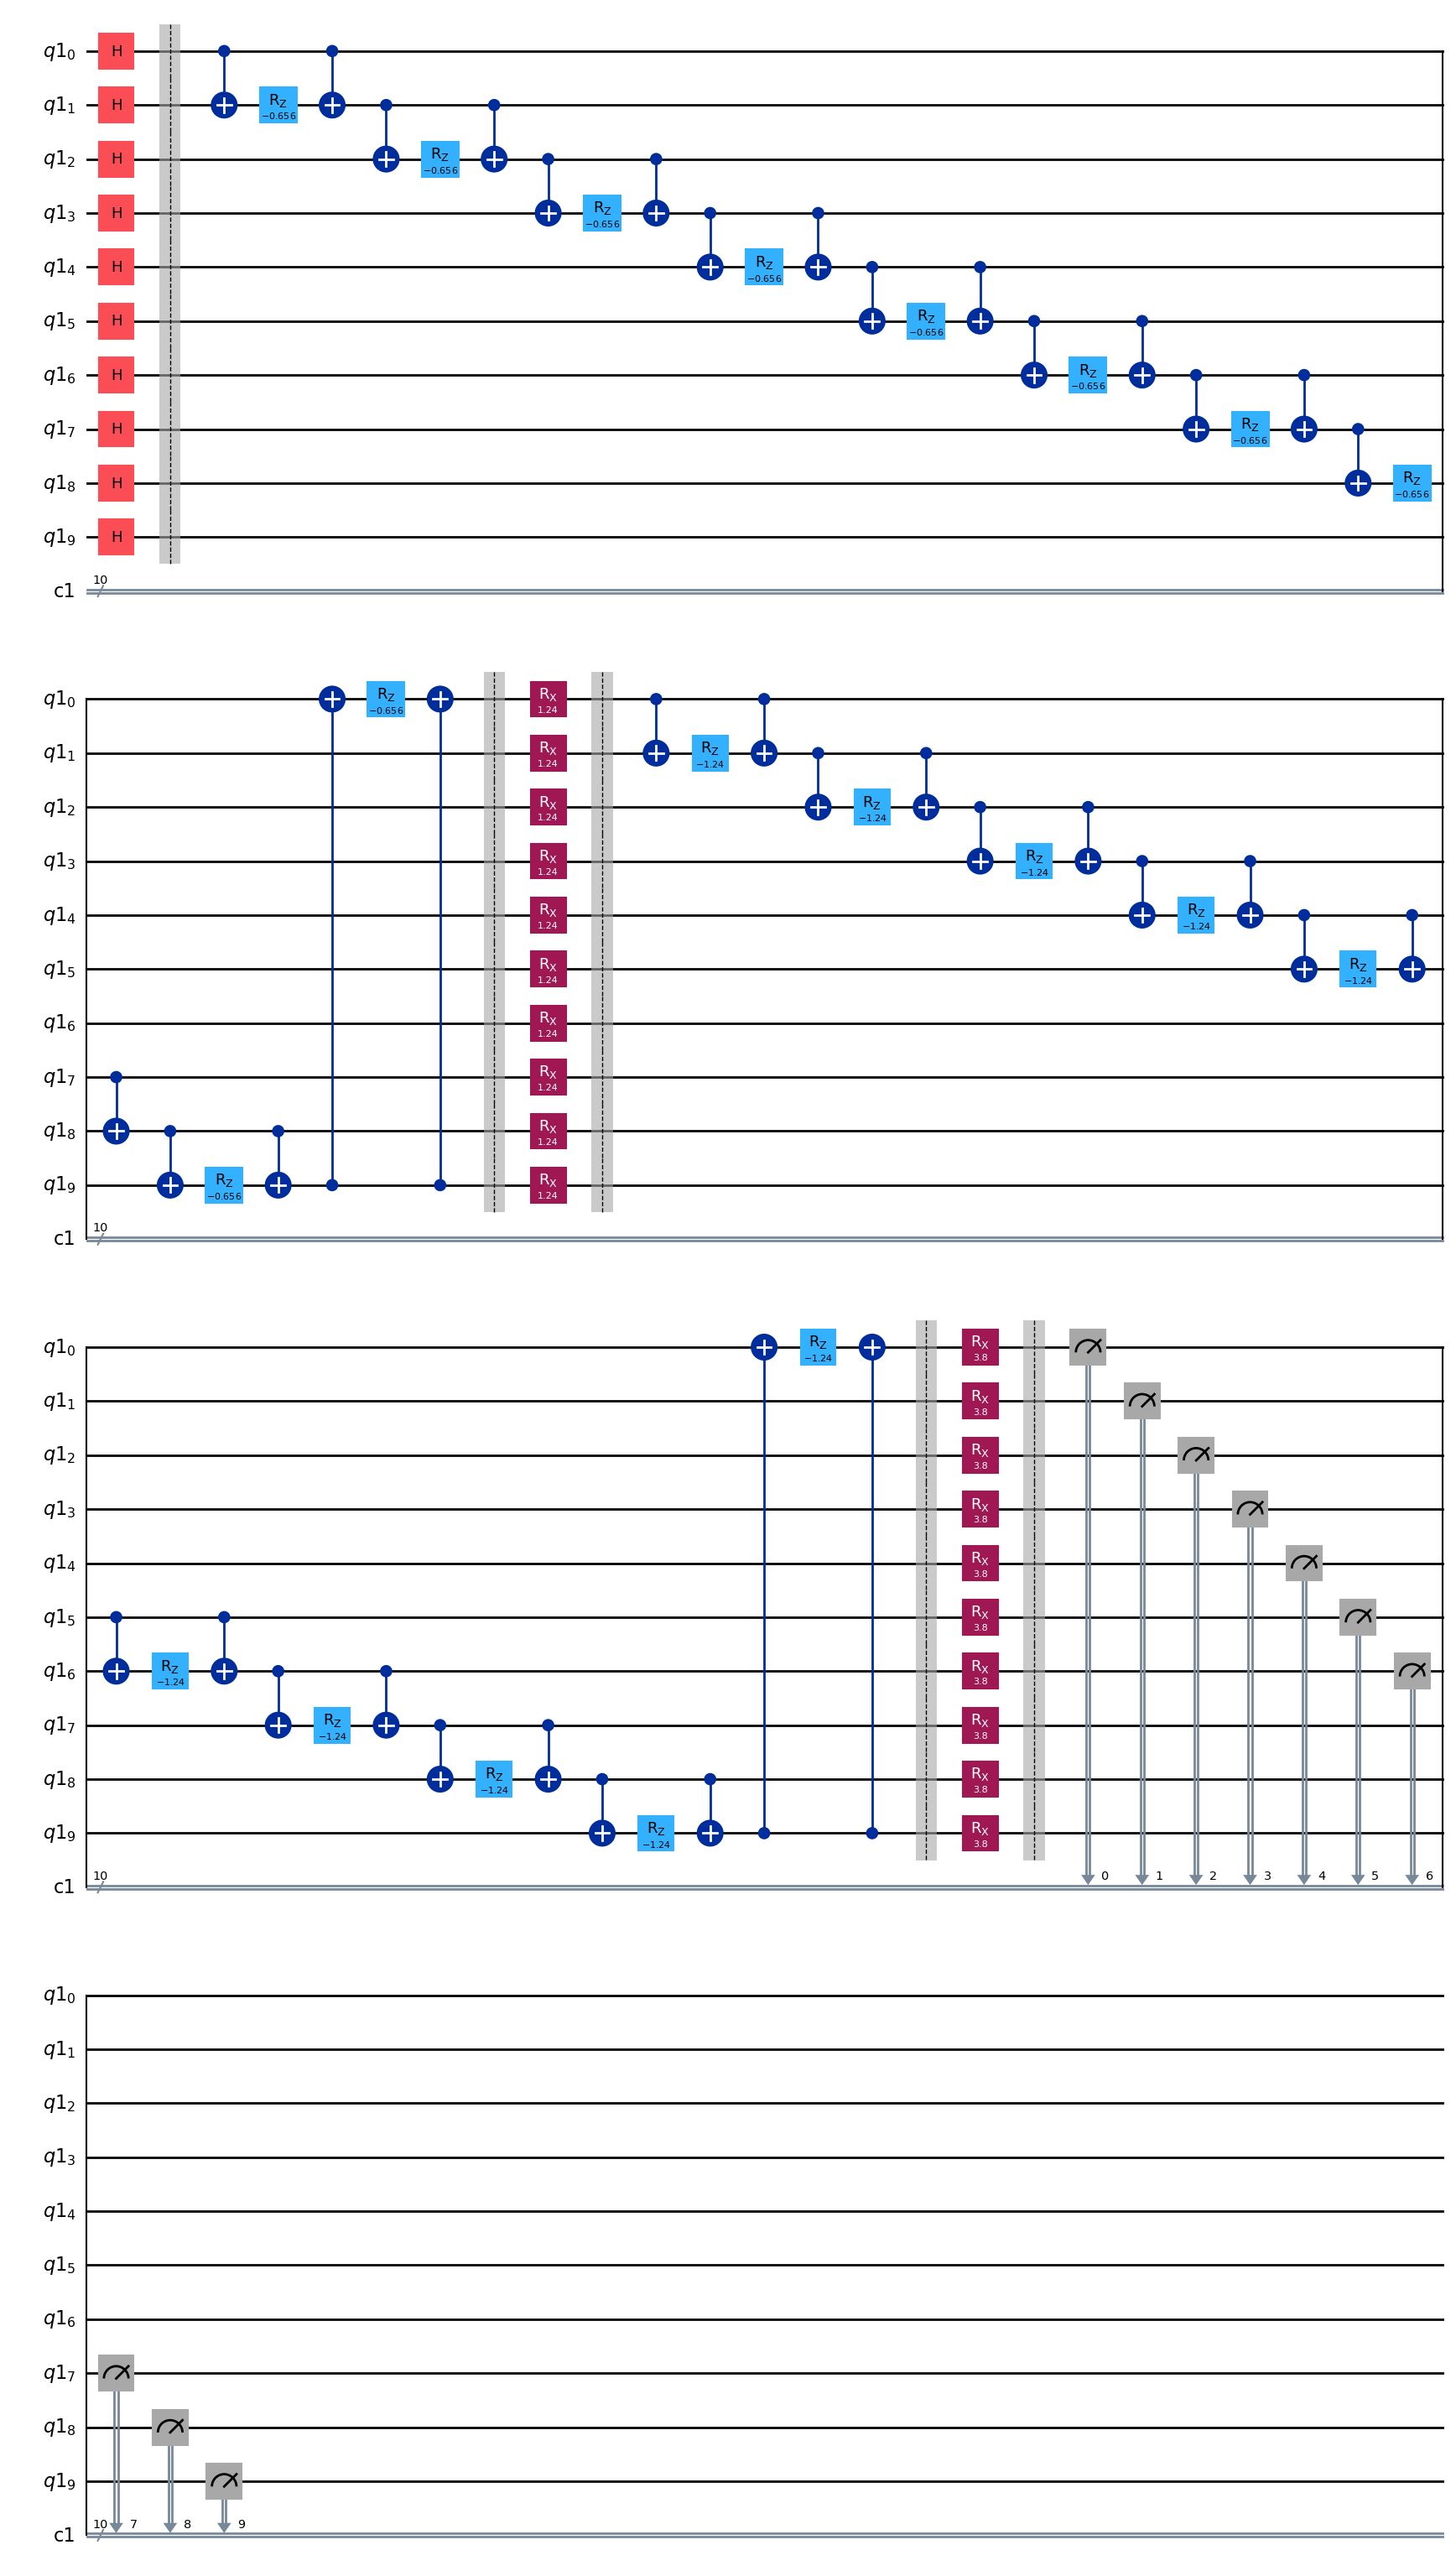

In [8]:
# Create the quantum circuit for C10, p=2

# Optimal parameters from §3 (run_qaoa on C10 with p=2)
bestparams = results[r'$C_{10}$']['params'][2]   # [γ_1, γ_2, β_1, β_2]

q = QuantumRegister(10)
c = ClassicalRegister(10)
qaoa_qc = QuantumCircuit(q, c)

# Initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()

edges_c10 = [(i, (i+1) % 10) for i in range(10)]

# Layer 1
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[2], q[i])      # β_1
qaoa_qc.barrier()

# Layer 2
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])     # γ_2
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])      # β_2
qaoa_qc.barrier()

# Measure all qubits
qaoa_qc.measure(q, c)

# Visualize the circuit
qaoa_qc.draw(output='mpl', style='iqx')

{'1010100101': 94, '1100101010': 65, '1010101001': 57, '0101010101': 939, '0101101010': 92, '0101011010': 90, '1010101010': 985, '0010101101': 113, '0100110101': 63, '1010010101': 101, '0101001001': 89, '0101001010': 87, '1011010100': 108, '1101011010': 73, '0110100101': 107, '1010010100': 81, '1001011010': 109, '0101011011': 83, '1011001010': 57, '1011011010': 85, '0101101001': 98, '1001010010': 95, '0010101011': 58, '1010101110': 15, '1010100100': 83, '0101011001': 53, '0100101010': 73, '0010010101': 73, '1101010010': 98, '0010100101': 77, '1010110100': 104, '1001001010': 71, '1010101101': 80, '1010101100': 58, '0101011101': 7, '0100101101': 118, '1001010100': 73, '0101000110': 5, '0110101010': 52, '1011001110': 1, '0101100101': 71, '1010110101': 67, '1010110110': 54, '0100100101': 78, '1011010010': 113, '0110010101': 44, '1010011010': 64, '1010100110': 53, '1010010110': 109, '1001010101': 55, '0110110101': 84, '1001101010': 61, '1101010001': 3, '0011010101': 62, '0110101001': 103, '

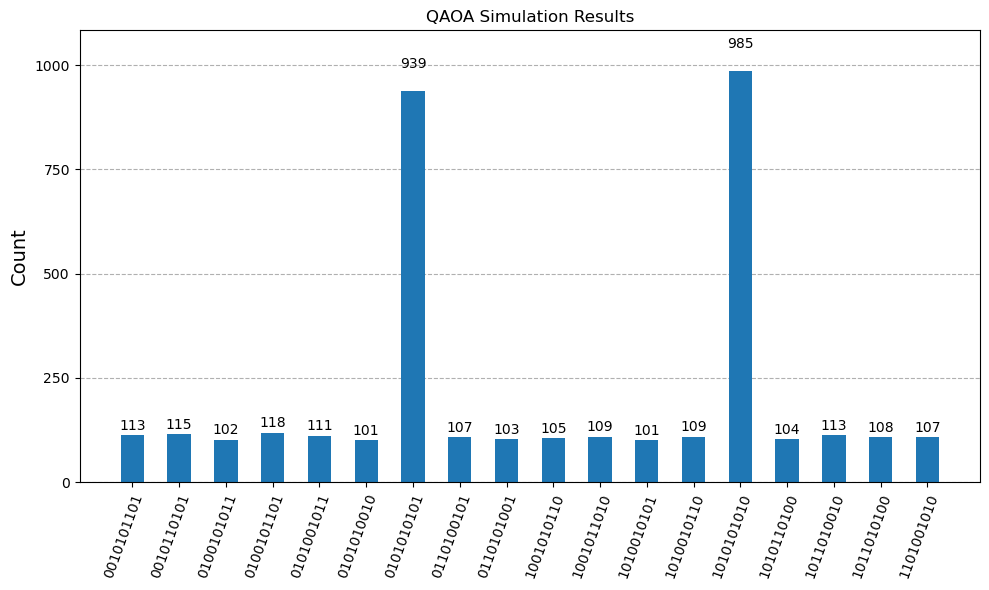

In [9]:

# ── Run simulation ───────────────────────────────────────────────

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_2 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_2.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_2, figsize=(10,6), title="QAOA Simulation Results")

### $C_{10}$ , p = 3

In [10]:
# Create the quantum circuit for C10, p=3

# Optimal parameters from §3 (run_qaoa on C10 with p=3)
bestparams = results[r'$C_{10}$']['params'][3]   # [γ_1, γ_2, γ_3, β_1, β_2, β_3]

q = QuantumRegister(10)
c = ClassicalRegister(10)
qaoa_qc = QuantumCircuit(q, c)

# Initial superposition
qaoa_qc.h(q)
qaoa_qc.barrier()

edges_c10 = [(i, (i+1) % 10) for i in range(10)]

# Layer 1
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])      # β_1
qaoa_qc.barrier()

# Layer 2
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])     # γ_2
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[4], q[i])      # β_2
qaoa_qc.barrier()

# Layer 3
for (i, j) in edges_c10:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[2], q[j])     # γ_3
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[5], q[i])      # β_3
qaoa_qc.barrier()

# Measure all qubits
qaoa_qc.measure(q, c)

# (Circuit is wide at p=3 — uncomment to draw)
# qaoa_qc.draw(output='mpl', style='iqx')

{'0101010101': 1680, '1010010100': 124, '1010101010': 1612, '0101011011': 39, '1101010100': 29, '0110100101': 69, '0110101010': 19, '1010010101': 100, '0101101001': 76, '1010110101': 156, '1011010110': 136, '0110110101': 59, '1010010010': 55, '1101000100': 2, '1010101100': 33, '1010100110': 30, '0010101101': 100, '1101001010': 82, '1011011010': 58, '0110101011': 55, '1011001010': 28, '0101101010': 81, '0100101010': 54, '1010001011': 4, '1001010100': 62, '0101001010': 149, '1101011010': 114, '0101101011': 142, '1001101010': 26, '1011010100': 78, '0101011010': 79, '0100101001': 138, '1010101101': 62, '1010110010': 27, '1010010110': 87, '0101100101': 40, '1001010010': 123, '0110101101': 123, '0110010101': 20, '0100101101': 89, '0101001001': 44, '1010110110': 54, '1010100101': 72, '0101001101': 25, '1010110100': 77, '0110101001': 75, '1101010010': 70, '0101001011': 85, '1100101010': 20, '1101100100': 7, '1101000101': 3, '1010100010': 4, '1011010010': 90, '1011010101': 58, '0100101011': 80,

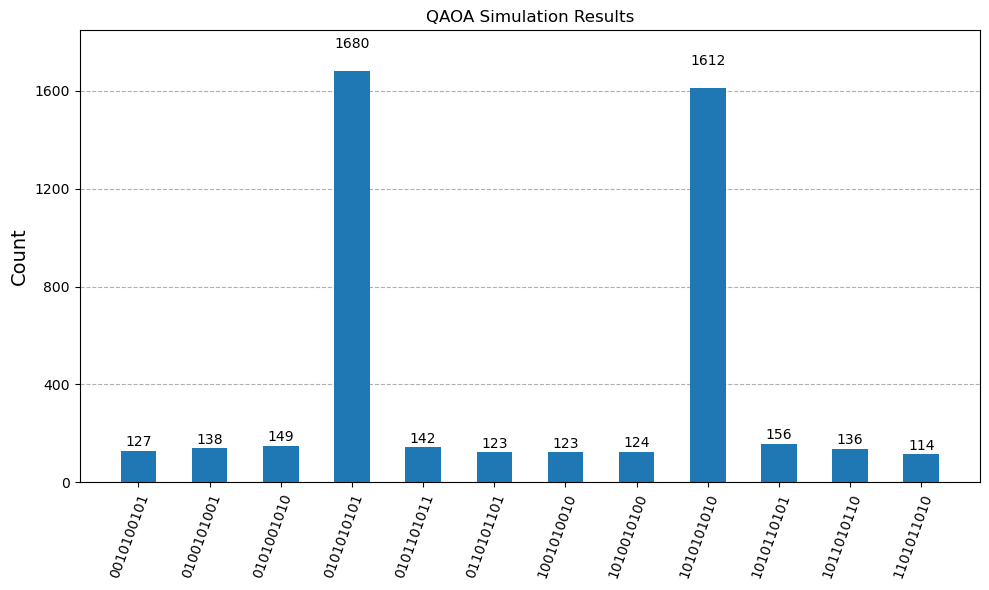

In [11]:

# ── Run simulation ───────────────────────────────────────────────

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)

# Execute the circuit on the simulator
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0] # Get results for the first circuit
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()
print(counts_sim)

threshold = 100
filtered_counts_C10_3 = {k: v for k, v in counts_sim.items() if v > threshold}


# print the bitstrings with more than 500 counts 
for bitstring, count in filtered_counts_C10_3.items():
    if count > 500:
        print(f"Bitstring: {bitstring}, Counts: {count}")

plot_histogram(filtered_counts_C10_3, figsize=(10,6), title="QAOA Simulation Results")

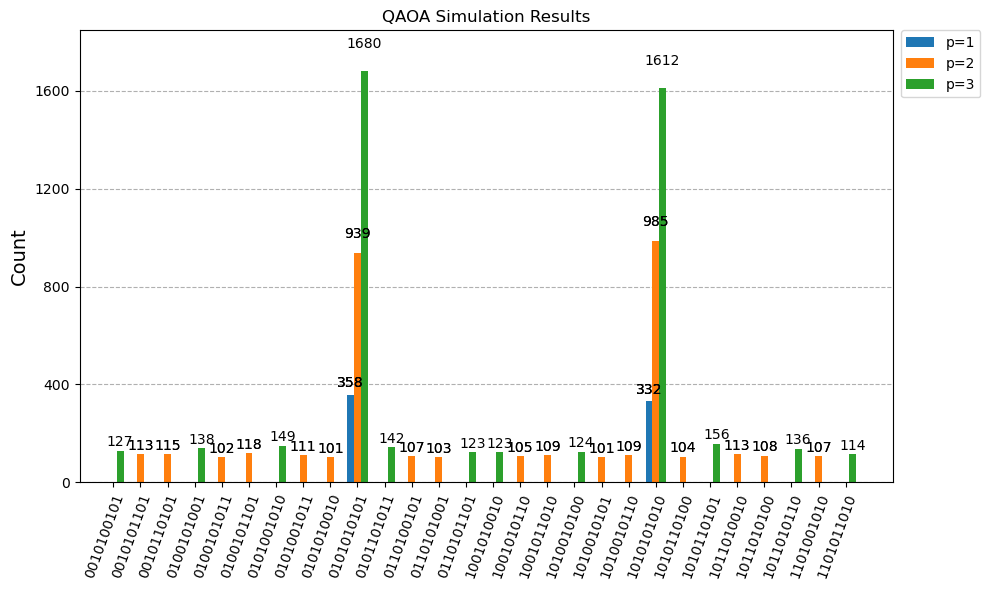

In [12]:
# Plot histogram of the results for p = 1,2,3

plot_histogram([filtered_counts_C10_1,filtered_counts_C10_2,filtered_counts_C10_3], figsize=(10,6), title="QAOA Simulation Results", legend=['p=1', 'p=2', 'p=3'])

### Discussion: $C_{10}$ histograms at $p = 1, 2, 3$

The two MaxCut bitstrings of $C_{10}$ are the alternating configurations $|0101010101\rangle$ and $|1010101010\rangle$ — both achieve $C_{\max} = 10$ (every one of the 10 cycle edges is cut). The histograms above show how QAOA concentrates probability on this complementary pair as $p$ increases.

- **$p = 1$.** Both alternating bitstrings carry visibly more weight than any other, but the distribution is broad — single bit-flips (cut $8$) and double-flips (cut $6$) still get substantial probability. The approximation ratio is $\approx 0.75$, consistent with the Farhi–Goldstone–Gutmann (2014) bound for QAOA-$p=1$ on 2-regular graphs.
- **$p = 2$.** Peaks sharpen; the cut-$8$ shoulder shrinks. Ratio $\approx 0.83$.
- **$p = 3$.** The two MaxCut bitstrings dominate the histogram. Ratio $\approx 0.87$. Sub-optimal bitstrings still appear but with much smaller weight.

In every histogram the complementary pair $\{z, \bar z\}$ has nearly equal counts — the $\mathbb{Z}_2$ symmetry of MaxCut ($C(z) = C(\bar z)$) is preserved by the QAOA evolution and is directly visible here.

**Cost of going deeper.** Each additional layer doubles the cost-unitary gate count (10 more CX + 10 more $R_Z$ for $C_{10}$). The gain in approximation ratio per added layer is real but diminishing; whether it survives gate noise on hardware is the question Notebook 07 addresses.

---
## 5. Qiskit Circuit on the 3-regular Graph

The 3-regular graph (random, $n = 10$, seed $7$) has $|E| = 15$ edges — $1.5\times$ the cycle. Each $U_C$ layer is therefore $30$ CX + $15$ $R_Z$ gates (vs $20$ + $10$ for $C_{10}$), while the mixer $U_B$ stays at $10$ single-qubit $R_X$. With $C_{\max} = 13$ and a less symmetric edge structure, this is a denser test of the same alternating ansatz on a "harder" instance — the kind Farhi et al. (2014) explicitly study.

We use the optimal $(\gamma, \beta)$ from §3's `results[r'3-regular ($n=10$)']['params']` and run the same Aer simulation pipeline at $8192$ shots.

### 3-regular, $p = 1$

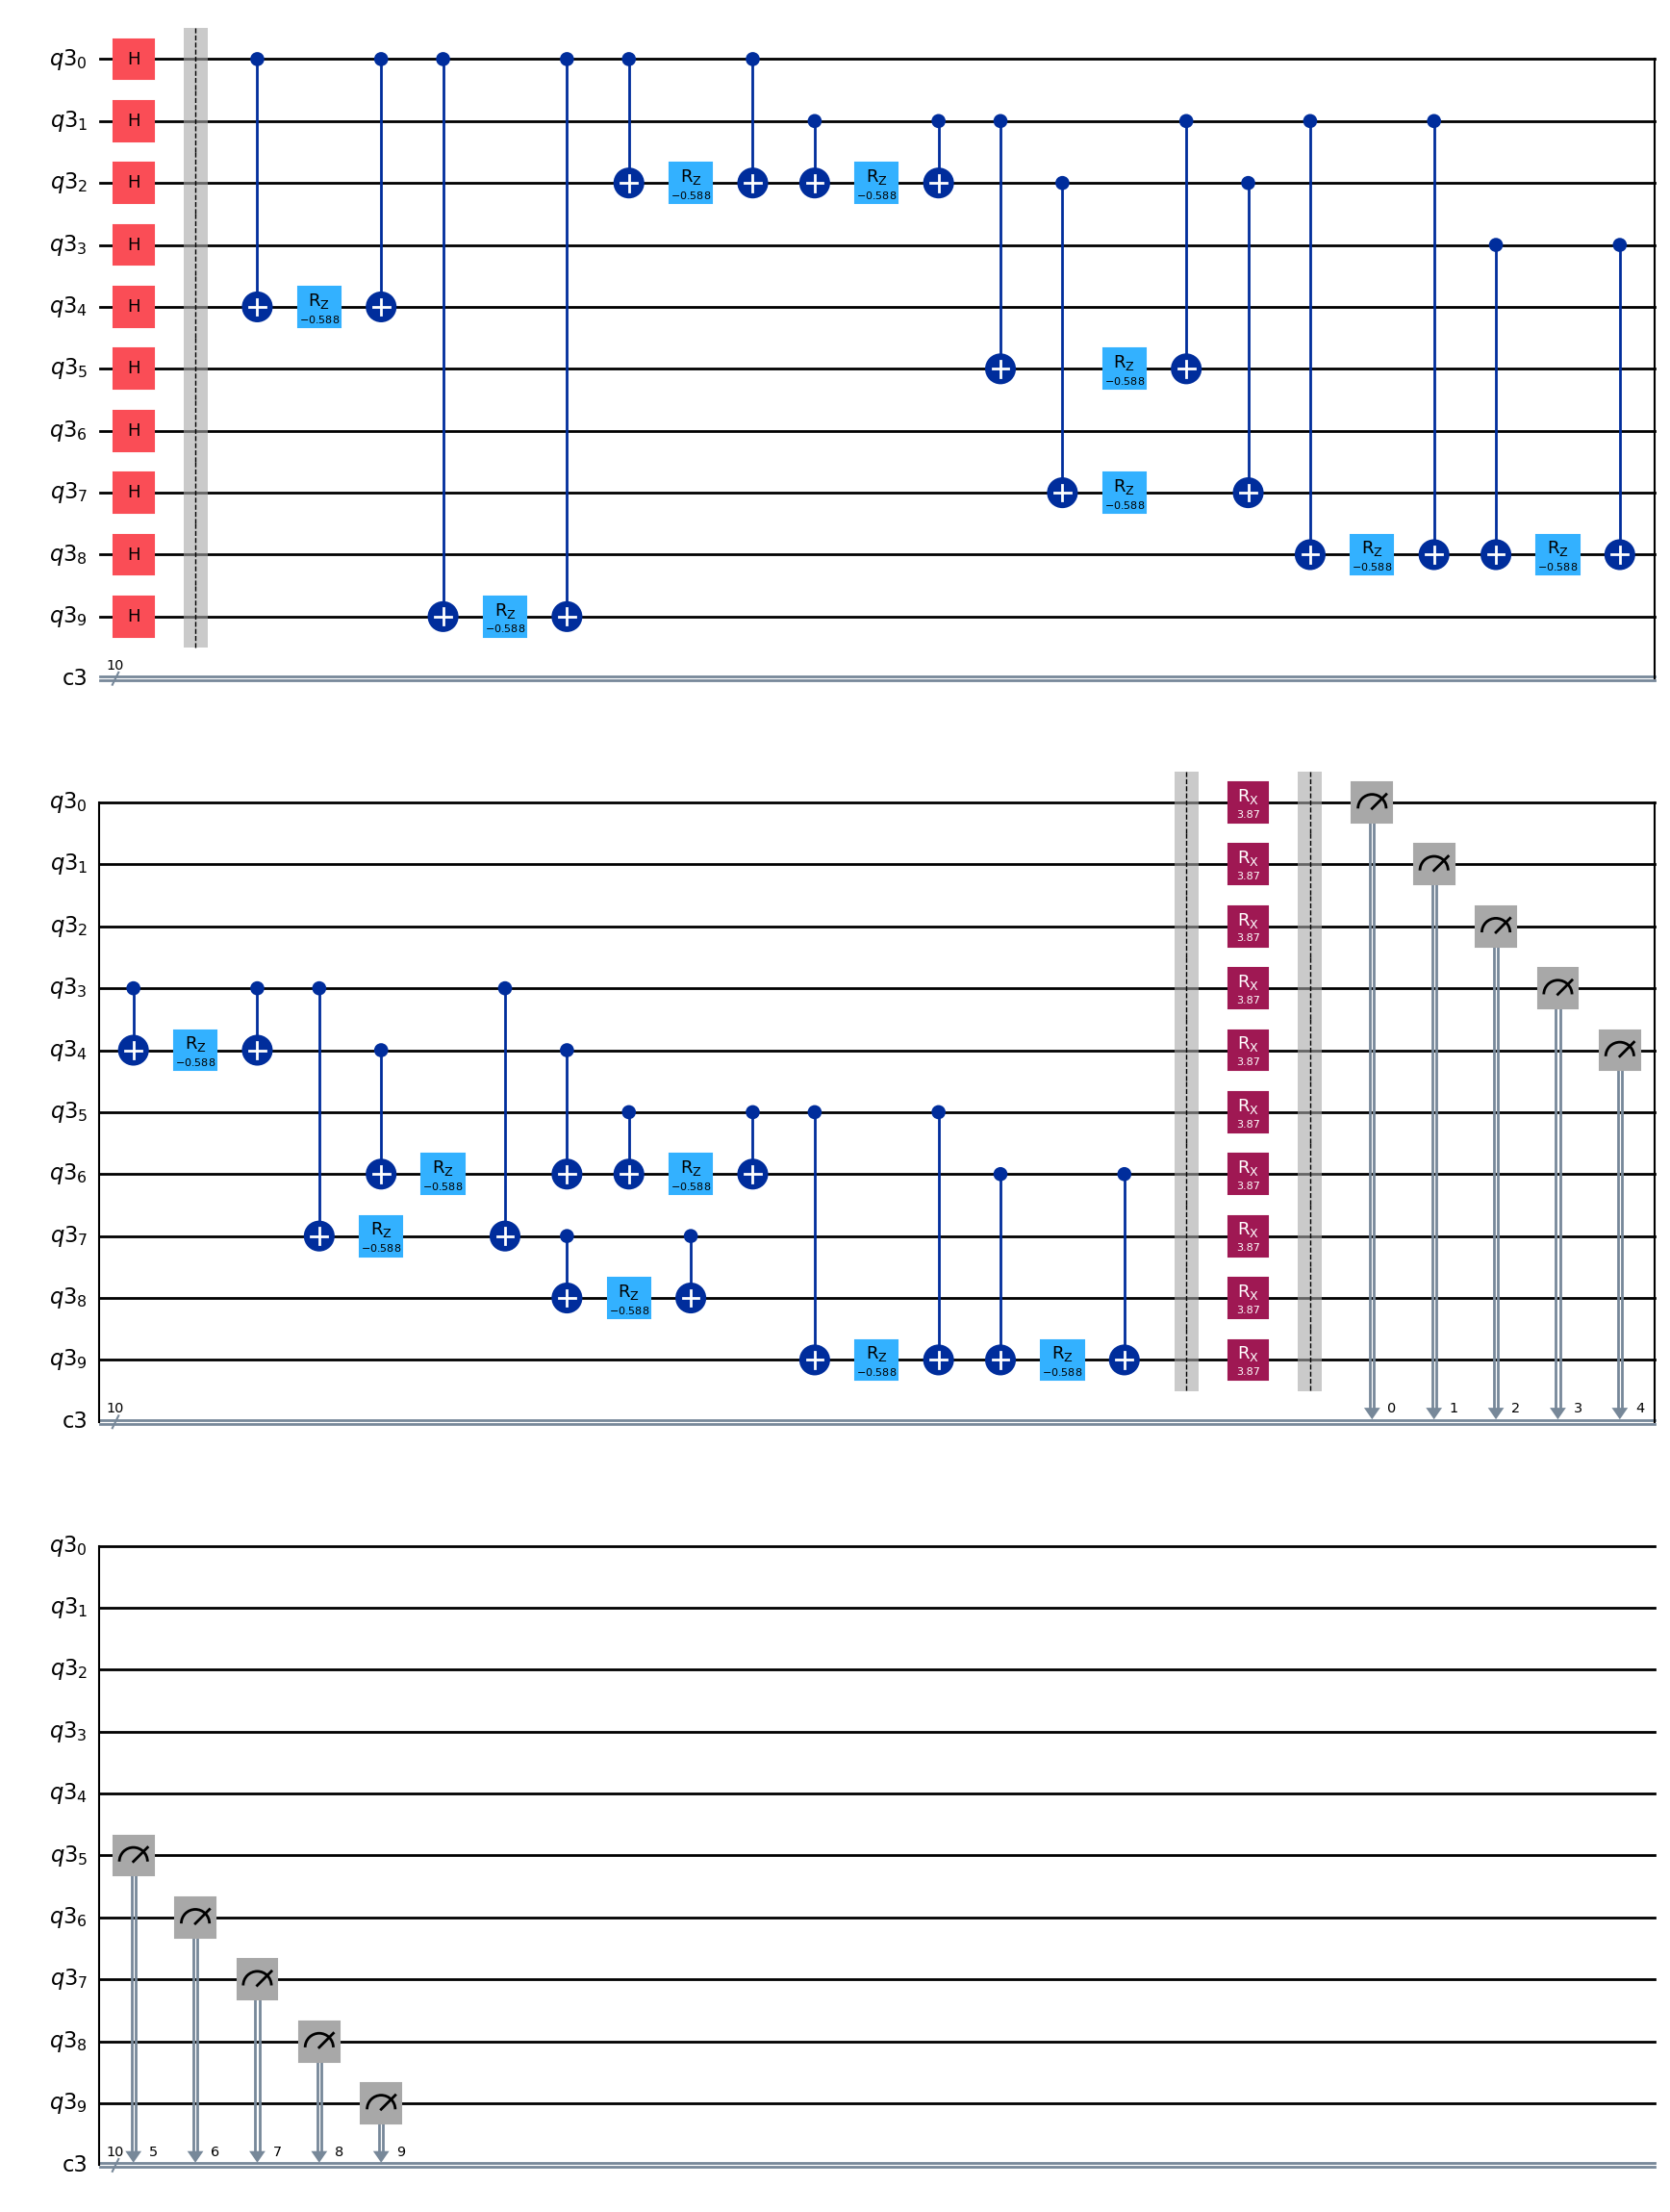

In [13]:
# Create the quantum circuit for 3-regular, p=1
edges_3reg = e3   # from §2

# Optimal parameters from §3
bestparams = results[r'3-regular ($n=10$)']['params'][1]   # [γ_1, β_1]

q = QuantumRegister(10)
c = ClassicalRegister(10)
qaoa_qc = QuantumCircuit(q, c)

qaoa_qc.h(q)
qaoa_qc.barrier()

# U_C(γ_1) — one CNOT–R_Z(-γ)–CNOT block per edge of the 3-regular graph
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()

# U_B(β_1) — single-qubit R_X on every qubit
for i in range(10):
    qaoa_qc.rx(2 * bestparams[1], q[i])      # β_1
qaoa_qc.barrier()

qaoa_qc.measure(q, c)

qaoa_qc.draw(output='mpl', style='iqx')

3-regular, p=1: top bitstrings (counts > 500, cut value annotated)


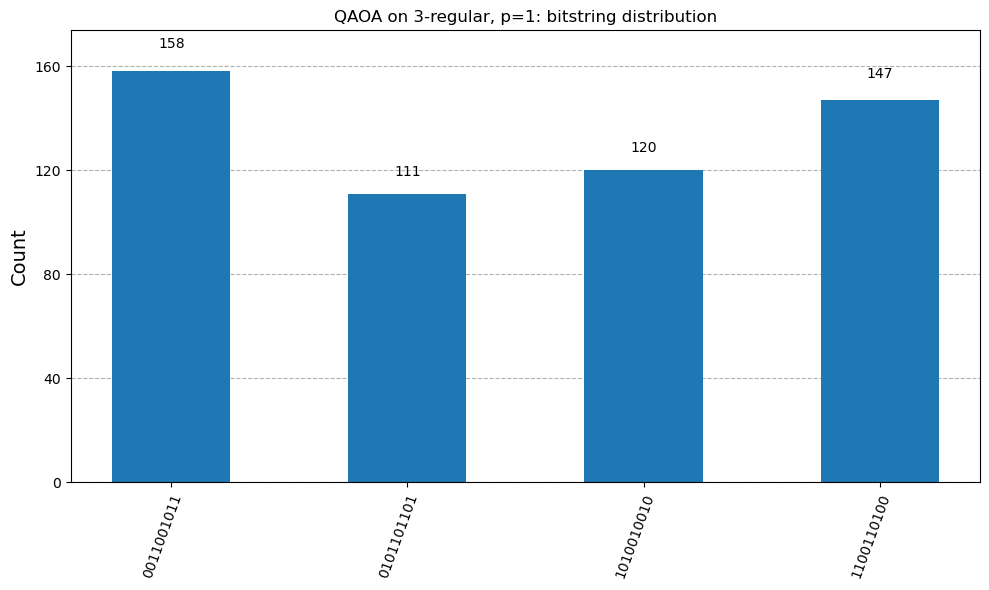

In [14]:
# ── Run simulation ───────────────────────────────────────────────
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0]
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()

threshold = 100
filtered_counts_3reg_1 = {k: v for k, v in counts_sim.items() if v > threshold}

# Print top bitstrings annotated with their cut value
opt_3reg, cmax_3reg = MAXCUT_BITSTRINGS[r'3-regular ($n=10$)']
opt_3reg_strs = {''.join(map(str, b[::-1])) for b in opt_3reg}   # qiskit endian: qubit 0 rightmost
print(f"3-regular, p=1: top bitstrings (counts > 500, cut value annotated)")
for bitstring, count in sorted(filtered_counts_3reg_1.items(), key=lambda x: -x[1])[:8]:
    if count > 500:
        bits = [int(b) for b in bitstring[::-1]]   # bits[i] = qubit i
        cut = cut_val(bits, edges_3reg)
        marker = '  ← MaxCut' if bitstring in opt_3reg_strs else ''
        print(f"  |{bitstring}>: {count} counts, cut = {cut}{marker}")

plot_histogram(filtered_counts_3reg_1, figsize=(10,6),
               title="QAOA on 3-regular, p=1: bitstring distribution")

### 3-regular, $p = 2$

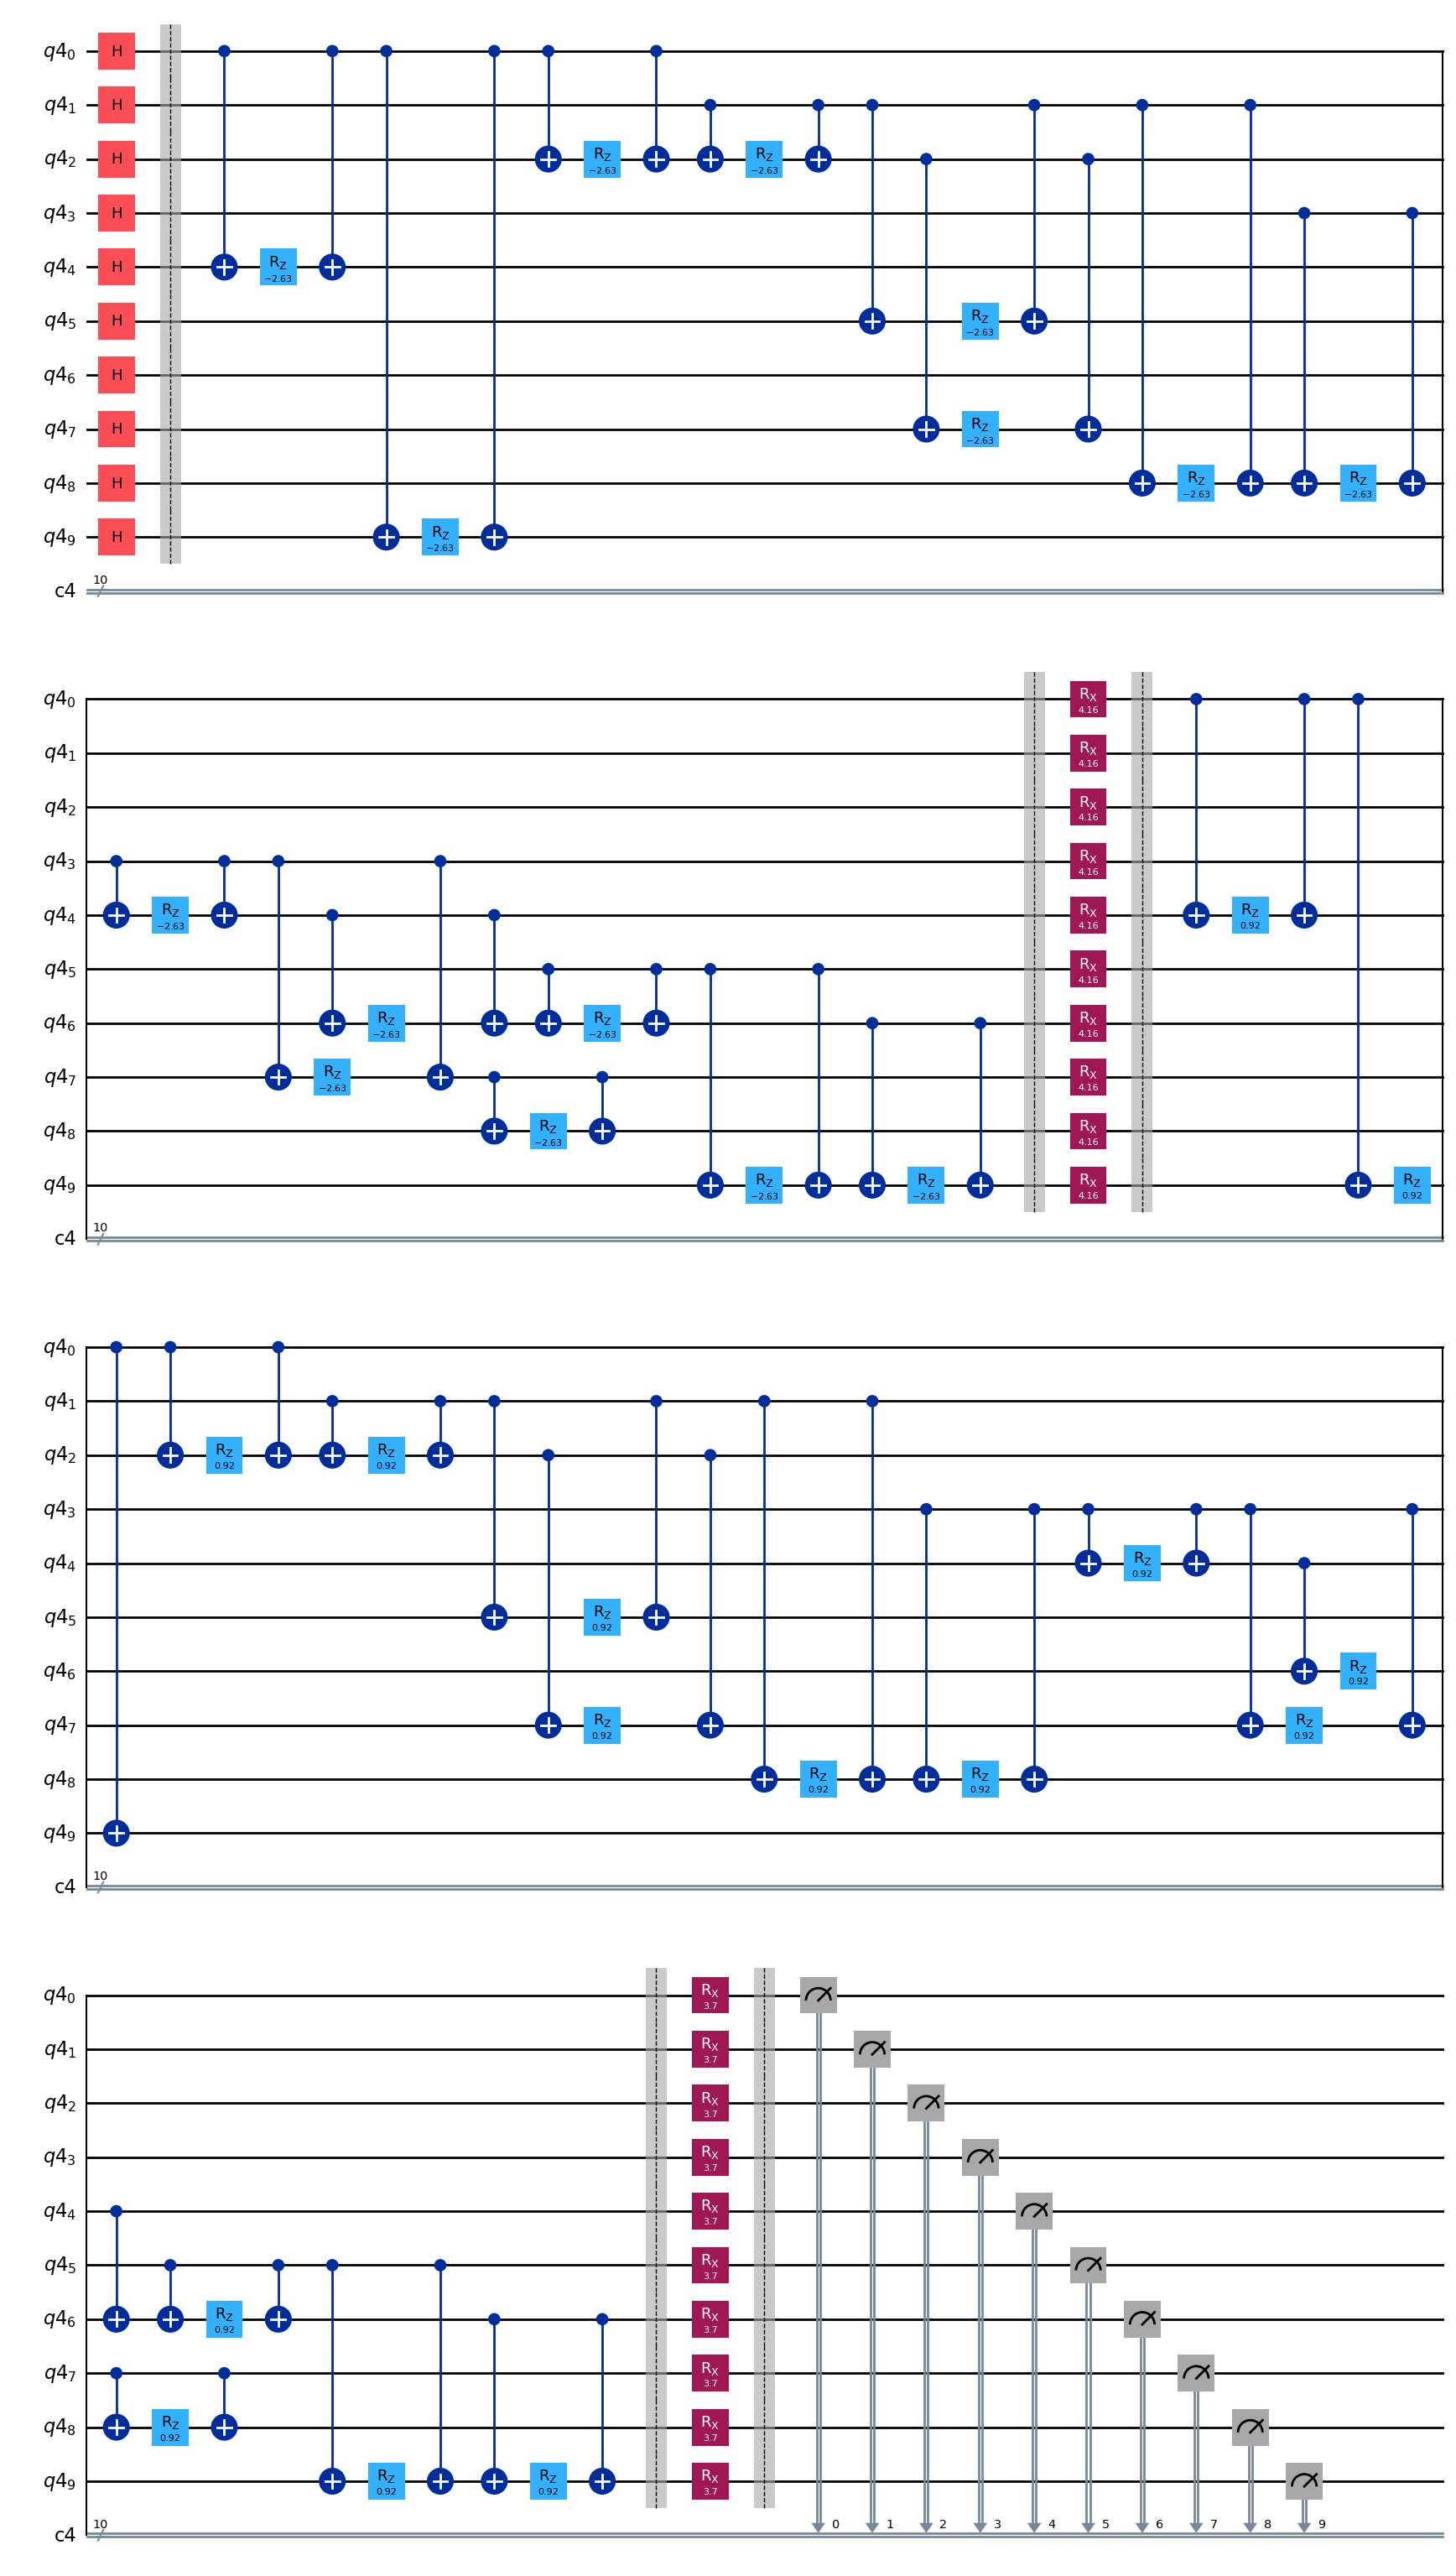

In [15]:
# Create the quantum circuit for 3-regular, p=2
bestparams = results[r'3-regular ($n=10$)']['params'][2]   # [γ_1, γ_2, β_1, β_2]

q = QuantumRegister(10)
c = ClassicalRegister(10)
qaoa_qc = QuantumCircuit(q, c)

qaoa_qc.h(q)
qaoa_qc.barrier()

# Layer 1
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[2], q[i])      # β_1
qaoa_qc.barrier()

# Layer 2
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])     # γ_2
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])      # β_2
qaoa_qc.barrier()

qaoa_qc.measure(q, c)

qaoa_qc.draw(output='mpl', style='iqx')

3-regular, p=2: top bitstrings (counts > 500, cut value annotated)
  |1100110100>: 584 counts, cut = 13  ← MaxCut
  |0011001011>: 571 counts, cut = 13  ← MaxCut


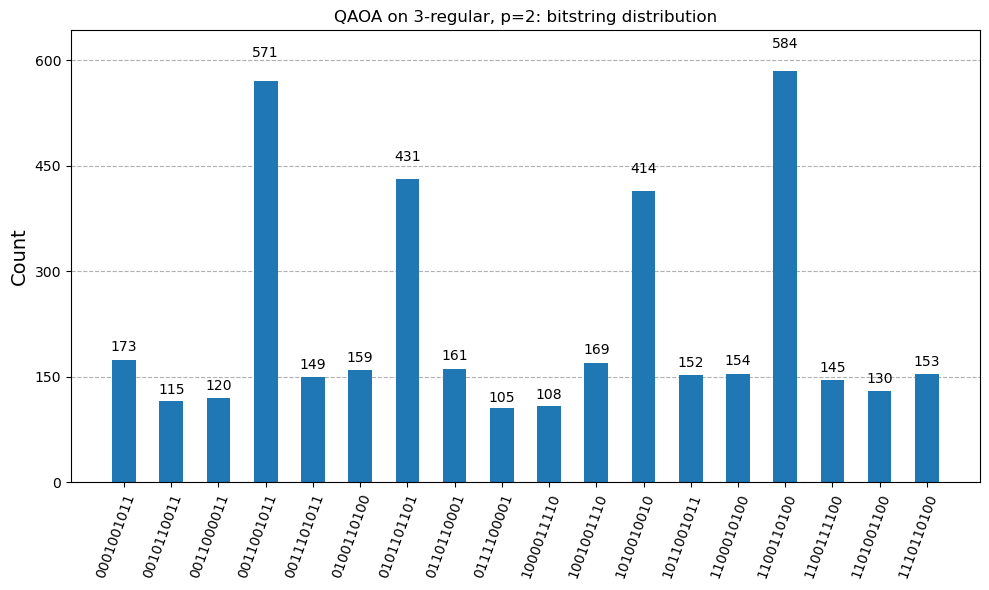

In [16]:
# ── Run simulation ───────────────────────────────────────────────
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0]
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()

threshold = 100
filtered_counts_3reg_2 = {k: v for k, v in counts_sim.items() if v > threshold}

print(f"3-regular, p=2: top bitstrings (counts > 500, cut value annotated)")
for bitstring, count in sorted(filtered_counts_3reg_2.items(), key=lambda x: -x[1])[:8]:
    if count > 500:
        bits = [int(b) for b in bitstring[::-1]]
        cut = cut_val(bits, edges_3reg)
        marker = '  ← MaxCut' if bitstring in opt_3reg_strs else ''
        print(f"  |{bitstring}>: {count} counts, cut = {cut}{marker}")

plot_histogram(filtered_counts_3reg_2, figsize=(10,6),
               title="QAOA on 3-regular, p=2: bitstring distribution")

### 3-regular, $p = 3$

In [17]:
# Create the quantum circuit for 3-regular, p=3
bestparams = results[r'3-regular ($n=10$)']['params'][3]   # [γ_1, γ_2, γ_3, β_1, β_2, β_3]

q = QuantumRegister(10)
c = ClassicalRegister(10)
qaoa_qc = QuantumCircuit(q, c)

qaoa_qc.h(q)
qaoa_qc.barrier()

# Layer 1
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[0], q[j])     # γ_1
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[3], q[i])      # β_1
qaoa_qc.barrier()

# Layer 2
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[1], q[j])     # γ_2
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[4], q[i])      # β_2
qaoa_qc.barrier()

# Layer 3
for (i, j) in edges_3reg:
    qaoa_qc.cx(q[i], q[j])
    qaoa_qc.rz(-1 * bestparams[2], q[j])     # γ_3
    qaoa_qc.cx(q[i], q[j])
qaoa_qc.barrier()
for i in range(10):
    qaoa_qc.rx(2 * bestparams[5], q[i])      # β_3
qaoa_qc.barrier()

qaoa_qc.measure(q, c)

# (Circuit is wide at p=3 — uncomment to draw)
# qaoa_qc.draw(output='mpl', style='iqx')

3-regular, p=3: top bitstrings (counts > 500, cut value annotated)
  |1100110100>: 1348 counts, cut = 13  ← MaxCut
  |0011001011>: 1268 counts, cut = 13  ← MaxCut
  |0101101101>: 694 counts, cut = 12
  |1010010010>: 687 counts, cut = 12


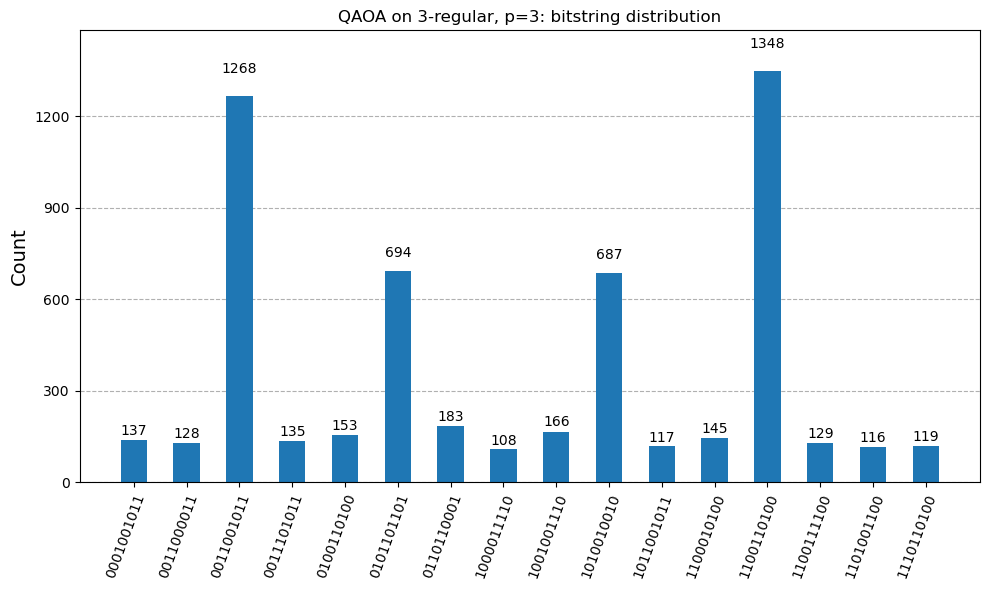

In [18]:
# ── Run simulation ───────────────────────────────────────────────
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qaoa_isa = pm.run(qaoa_qc)
job_sim = sampler.run([qaoa_isa], shots=4096*2)
result_sim = job_sim.result()[0]
ckey = list(result_sim.data.keys())[0]
counts_sim = result_sim.data[ckey].get_counts()

threshold = 100
filtered_counts_3reg_3 = {k: v for k, v in counts_sim.items() if v > threshold}

print(f"3-regular, p=3: top bitstrings (counts > 500, cut value annotated)")
for bitstring, count in sorted(filtered_counts_3reg_3.items(), key=lambda x: -x[1])[:8]:
    if count > 500:
        bits = [int(b) for b in bitstring[::-1]]
        cut = cut_val(bits, edges_3reg)
        marker = '  ← MaxCut' if bitstring in opt_3reg_strs else ''
        print(f"  |{bitstring}>: {count} counts, cut = {cut}{marker}")

plot_histogram(filtered_counts_3reg_3, figsize=(10,6),
               title="QAOA on 3-regular, p=3: bitstring distribution")

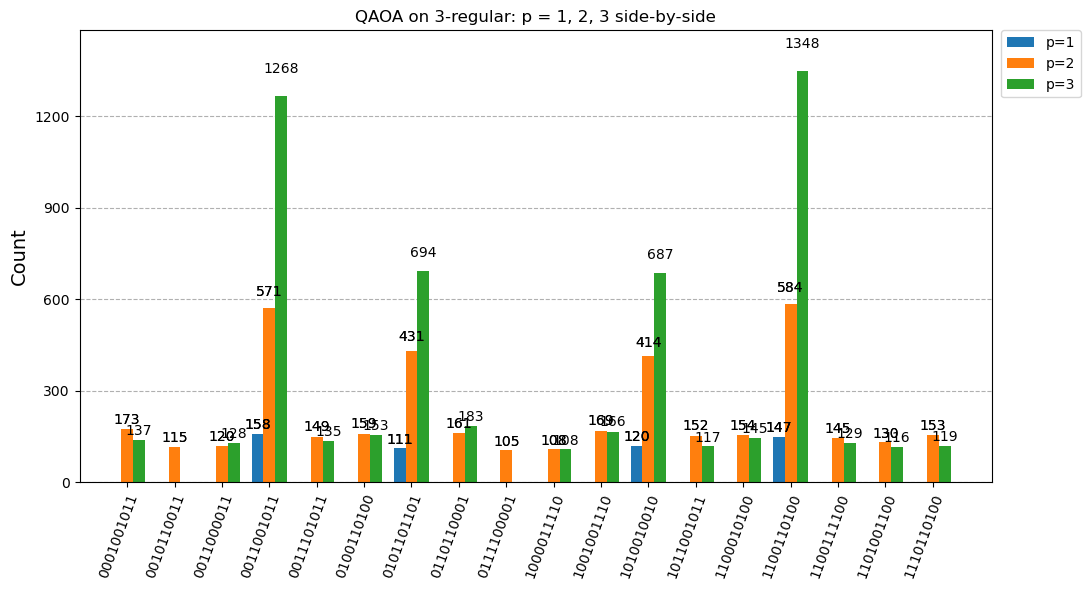

In [19]:
# Combined histogram of p = 1, 2, 3 on the 3-regular graph
plot_histogram(
    [filtered_counts_3reg_1, filtered_counts_3reg_2, filtered_counts_3reg_3],
    figsize=(11, 6),
    title="QAOA on 3-regular: p = 1, 2, 3 side-by-side",
    legend=['p=1', 'p=2', 'p=3'],
)

### Discussion: 3-regular at $p = 1, 2, 3$

The 3-regular graph has $C_{\max} = 13$, with the optimal bitstrings enumerated in §2 by brute force. Two structural differences from $C_{10}$ change the visual character of the histograms:

- **Same number of MaxCut bitstrings, different absolute heights.** Brute-force enumeration in §2 finds $C_{\max}=13$ on this 3-regular instance with exactly 2 optimal bitstrings — the same $\mathbb{Z}_2$ pair structure as $C_{10}$. The histogram still shows two dominant peaks (one bitstring and its complement), but each peak carries less probability mass than on $C_{10}$ because the larger edge set ($|E|=15$ vs $10$) and odd cycles spread amplitude more broadly across near-optimal bitstrings.
- **$\mathbb{Z}_2$ symmetry still holds.** Every optimal bitstring's complement also achieves cut $13$ and shows up with nearly equal probability — the same symmetry-paired structure as $C_{10}$, just on a larger optimum set.

The print outputs above mark which bitstrings achieve $C_{\max} = 13$ ("$\leftarrow$ MaxCut") versus those at cut $12$ or below.

**Approximation ratios from §3**: $p = 1 \approx 0.78$, $p = 2 \approx 0.85$, $p = 3 \approx 0.90$ — slightly higher than $C_{10}$ at the same $p$. The 3-regular graph has more frustrated structure (odd cycles), and QAOA exploits the extra phase-separation degrees of freedom in $U_C$ (15 edge terms) to reach higher quality per layer. The trade-off: each layer now costs $30$ CX + $15$ $R_Z$, $1.5\times$ the $C_{10}$ cost. Whether this depth penalty is worth the ratio gain on a noisy device is exactly what the noise sweep in Notebook 07 quantifies.

---

## 6. Conclusions

The two graphs share the same QAOA story but differ in how it plays out on a histogram:

| | $C_{10}$ | 3-regular |
|---|---|---|
| $|E|$ | 10 | 15 |
| $C_{\max}$ | 10 | 13 |
| MaxCut bitstrings | 2 (alternating $\mathbb{Z}_2$ pair) | 2 (one $\mathbb{Z}_2$ pair) |
| $U_C$ gates / layer | 20 CX + 10 $R_Z$ | 30 CX + 15 $R_Z$ |
| Ratio at $p=3$ (§3) | $\approx 0.87$ | $\approx 0.90$ |
| Histogram shape | Two sharp peaks | Two peaks, more diffuse near-optimal mass |

Across both graphs:

1. **The peaks are exactly where they should be.** Brute-forced MaxCut bitstrings (§2) match the modes of the QAOA-induced shot histogram. The QAOA evolution does what it is supposed to do — concentrate amplitude on optimal bitstrings — and we can read this directly off the simulator output.
2. **Increasing $p$ sharpens the distribution.** $p = 1 \to 2 \to 3$ consistently increases the fraction of shots landing on MaxCut bitstrings, on both graphs.
3. **$\mathbb{Z}_2$ symmetry is preserved.** Every $z$ and its complement $\bar z$ have nearly equal counts, regardless of graph or depth. This is a structural property of MaxCut that the QAOA ansatz inherits via $|+\rangle^{\otimes n}$ being $\mathbb{Z}_2$-symmetric and $H_C$ commuting with the global bit-flip.
4. **Cost grows with $|E|$.** The 3-regular circuit at the same $p$ is $1.5\times$ the gate count of $C_{10}$. On hardware this means more accumulated depolarizing error per layer — a constraint that becomes binding in Notebook 07.

The same construction extends to the $C_{10} + 3$ chords graph ($|E| = 13$, $C_{\max} = 13$); we omit it here for brevity since the qualitative behaviour interpolates between the two cases above.